In [4]:
import pandas as pd
import sklearn
import seaborn as sns
import mlflow

print("Everything is working!")

Everything is working!


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import mlflow

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [6]:
df = sns.load_dataset("titanic")

print("Shape:", df.shape)
display(df.head())

print(df.info())

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


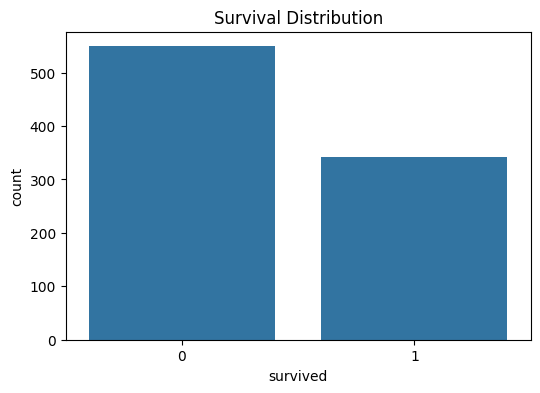

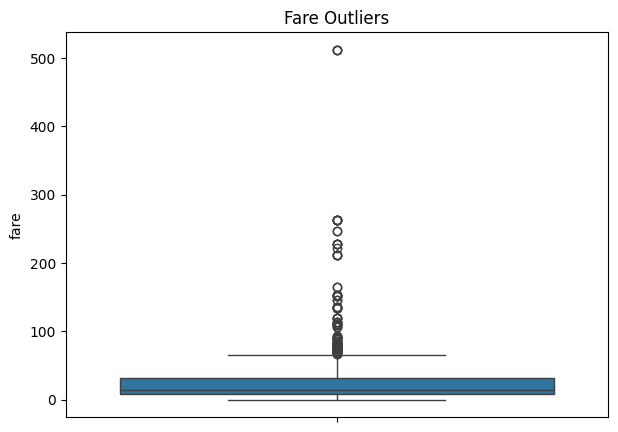

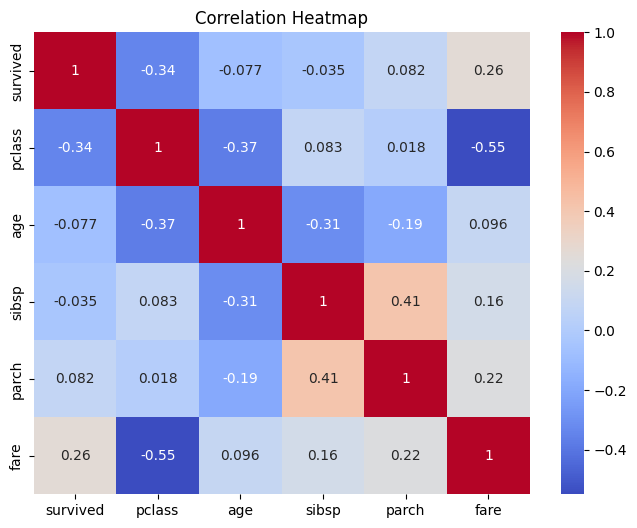

In [7]:
print(df.isnull().sum())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="survived")
plt.title("Survival Distribution")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(y=df["fare"])
plt.title("Fare Outliers")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [11]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]
y = df["survived"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


In [14]:
numeric_features = [
    "age",
    "fare",
    "sibsp",
    "parch",
    "pclass"
]

categorical_features = [
    "sex",
    "embarked"
]

In [15]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Pipeline Created")

Pipeline Created


In [16]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train Shape:", X_train_processed.shape)
print("Test Shape:", X_test_processed.shape)

Train Shape: (712, 10)
Test Shape: (179, 10)


In [17]:
train_df = pd.DataFrame(X_train_processed.toarray()
                        if hasattr(X_train_processed, "toarray")
                        else X_train_processed)

test_df = pd.DataFrame(X_test_processed.toarray()
                       if hasattr(X_test_processed, "toarray")
                       else X_test_processed)

train_df["target"] = y_train.reset_index(drop=True)
test_df["target"] = y_test.reset_index(drop=True)

train_df.to_csv("titanic_train_processed.csv", index=False)
test_df.to_csv("titanic_test_processed.csv", index=False)

print("Files Saved Successfully")

Files Saved Successfully


In [18]:
mlflow.set_experiment("Week2_Preprocessing")

with mlflow.start_run():

    mlflow.log_param("dataset", "Titanic")
    mlflow.log_param("missing_strategy", "Median + Most Frequent")
    mlflow.log_param("encoding", "OneHotEncoder")
    mlflow.log_param("scaling", "StandardScaler")

    mlflow.log_metric("train_rows", train_df.shape[0])
    mlflow.log_metric("test_rows", test_df.shape[0])

    print("MLflow Logged Successfully")

2026/08/02 13:50:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/02 13:50:11 INFO mlflow.store.db.utils: Updating database tables
2026/08/02 13:50:19 INFO mlflow.tracking.fluent: Experiment with name 'Week2_Preprocessing' does not exist. Creating a new experiment.


MLflow Logged Successfully


In [20]:
assert train_df.shape[0] > 0
assert test_df.shape[0] > 0

assert "target" in train_df.columns
assert "target" in test_df.columns

print("All Tests Passed")

All Tests Passed
